In [1]:
!pip install wilds matplotlib torch torchvision terratorch umap-learn seaborn scikit-learn matplotlib


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [2]:

import ClusteringPipeline
# ---------------------------------------------------------
#  Simplified DataLoader
# ---------------------------------------------------------
import torch
from pathlib import Path
from PIL import Image
import torchvision.transforms as T
from terratorch.models.backbones.terramind.model.terramind_register import v1_pretraining_mean, v1_pretraining_std

my_root_path = "/mnt/windows/Users/kevin/Downloads/"
def get_input(idx):
        """
        Returns x for a given idx.
        """
        img = Image.open(Path(my_root_path + 'fmow_v1.1') / 'images' / f'rgb_img_{idx}.png').convert('RGB')
        return img



# 1. Fetch the 8-bit RGB specific statistics
tm_rgb_mean = v1_pretraining_mean['untok_sen2rgb@224']
tm_rgb_std = v1_pretraining_std['untok_sen2rgb@224']

# 2. Scale the stats down to 0.0-1.0 to match T.ToTensor()
SCALED_MEAN = [x / 255.0 for x in tm_rgb_mean]
SCALED_STD = [x / 255.0 for x in tm_rgb_std]

print(f"Scaled RGB Mean: {SCALED_MEAN}")
print(f"Scaled RGB Std:  {SCALED_STD}")

# 3. Create the Transform Pipeline
terramind_transform = T.Compose([
    T.ToTensor(),  # Scales 0-255 pixels down to 0.0-1.0
    T.Normalize(mean=SCALED_MEAN, std=SCALED_STD) # Perfectly standardizes the data
])




/home/kevinthomaj/PyCharmMiscProject/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Scaled RGB Mean: [0.3422392156862745, 0.31737647058823526, 0.26143921568627454]
Scaled RGB Std:  [0.23045882352941177, 0.18691372549019605, 0.16718039215686276]


In [16]:
import torch.nn as nn
class SimpleMLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=32, num_classes=6):
        super(SimpleMLP, self).__init__()
        self.layer_stack = nn.Sequential(
            # Input to Hidden
            nn.Linear(input_dim, hidden_dim),
            nn.BatchNorm1d(hidden_dim),
            nn.GELU(),
            # Optional: Dropout helps significantly with 64 samples/class
            nn.Dropout(0.3),
            # Hidden to Output
            nn.Linear(hidden_dim, num_classes)
        )

    def forward(self, x):
        return self.layer_stack(x)
class LinearProbe(nn.Module):
    def __init__(self, input_dim, num_classes=62):
        super(LinearProbe, self).__init__()
        # Nessun hidden layer, solo una proiezione diretta
        self.classifier = nn.Sequential(
            nn.Linear(input_dim, num_classes),
        )

    def forward(self, x):
        return self.classifier(x)

2026-04-17 16:22:01,390 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-small/resolve/main/TerraMind_v1_small.pt "HTTP/1.1 302 Found"
2026-04-17 16:22:03,526 - INFO - HTTP Request: HEAD https://huggingface.co/ibm-esa-geospatial/TerraMind-1.0-tiny/resolve/main/TerraMind_v1_tiny.pt "HTTP/1.1 302 Found"


--- Sampling 100 images per class ---
Extracting features...


Extracting: 100%|██████████| 40/40 [05:24<00:00,  8.10s/it]


Saving new embeddings dataset to disk...
Clustering embeddings...
Distribution of images across the new macro-classes:
macro_class
1    1939
2    1700
4     725
3     482
5     257
6       9
Name: count, dtype: int64


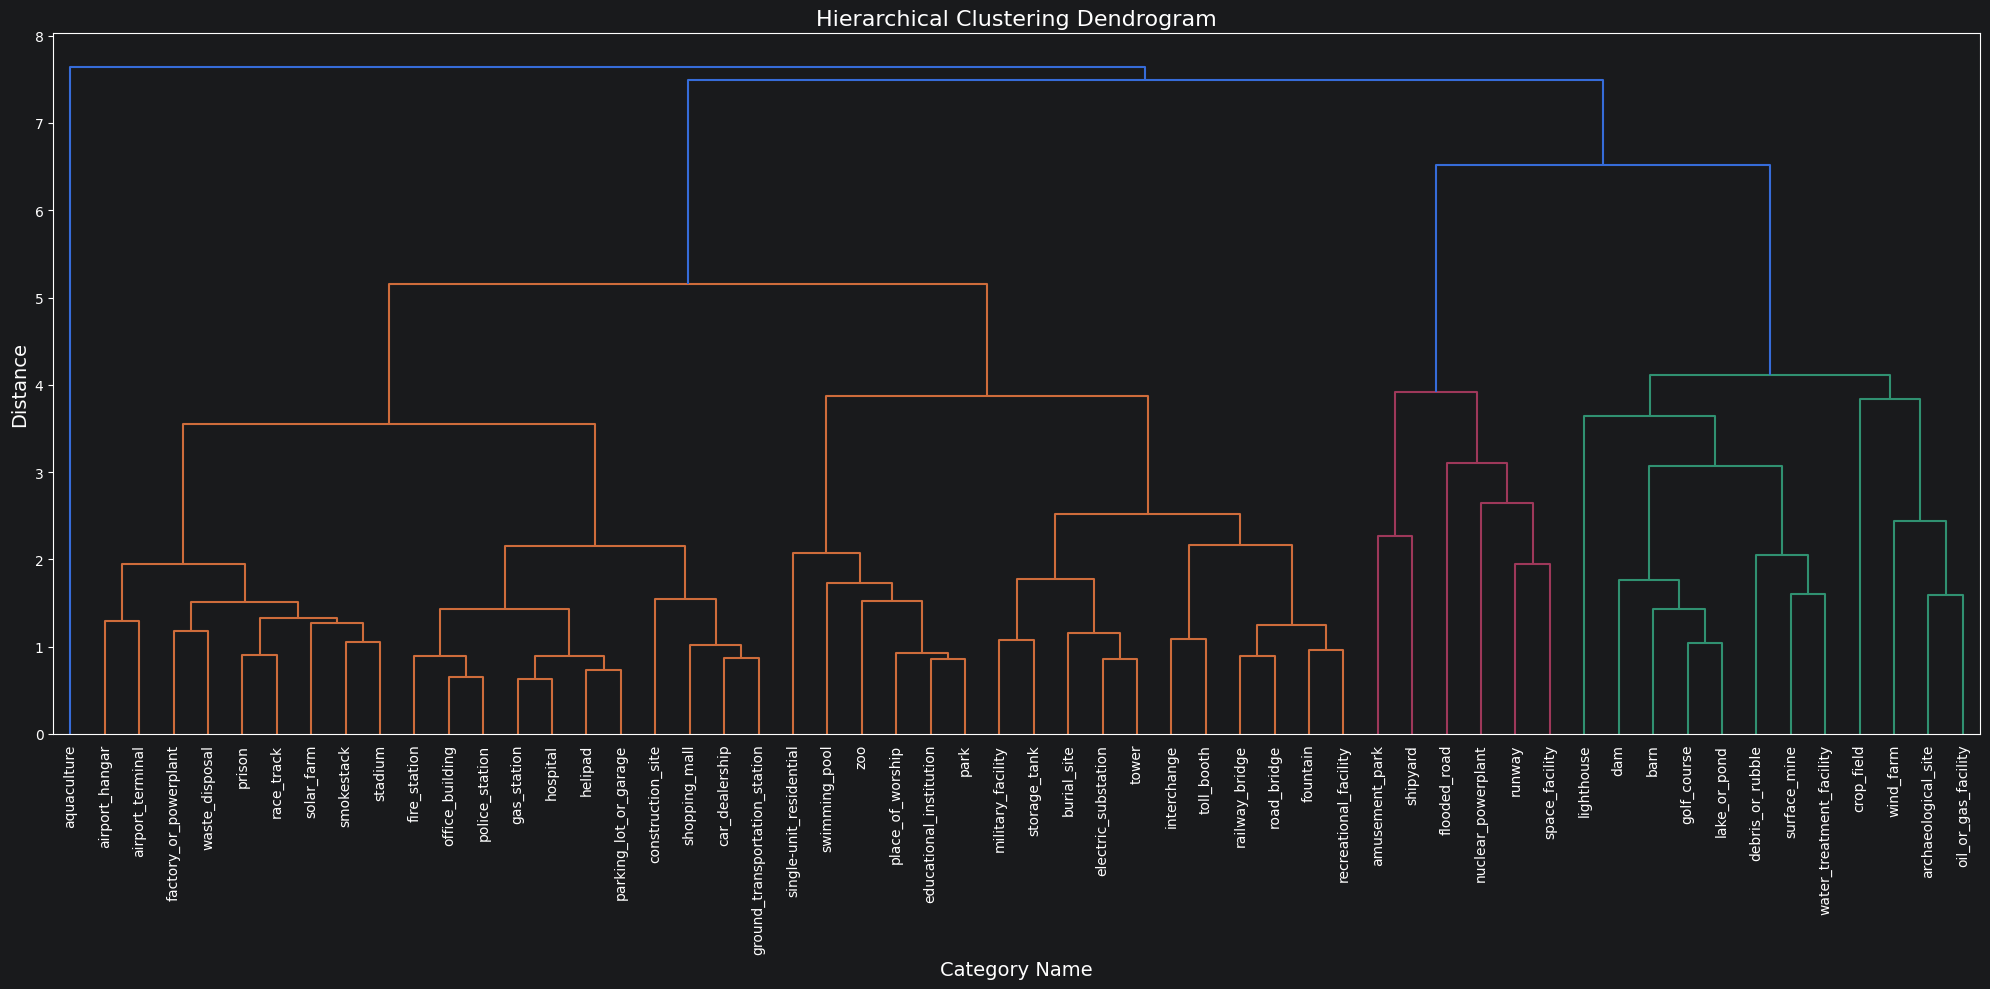

Extracting features...


Extracting: 100%|██████████| 40/40 [02:02<00:00,  3.06s/it]


Saving new embeddings dataset to disk...
Clustering embeddings...
Distribution of images across the new macro-classes:
macro_class
6    2039
3    1589
2     800
5     382
1     193
4     109
Name: count, dtype: int64


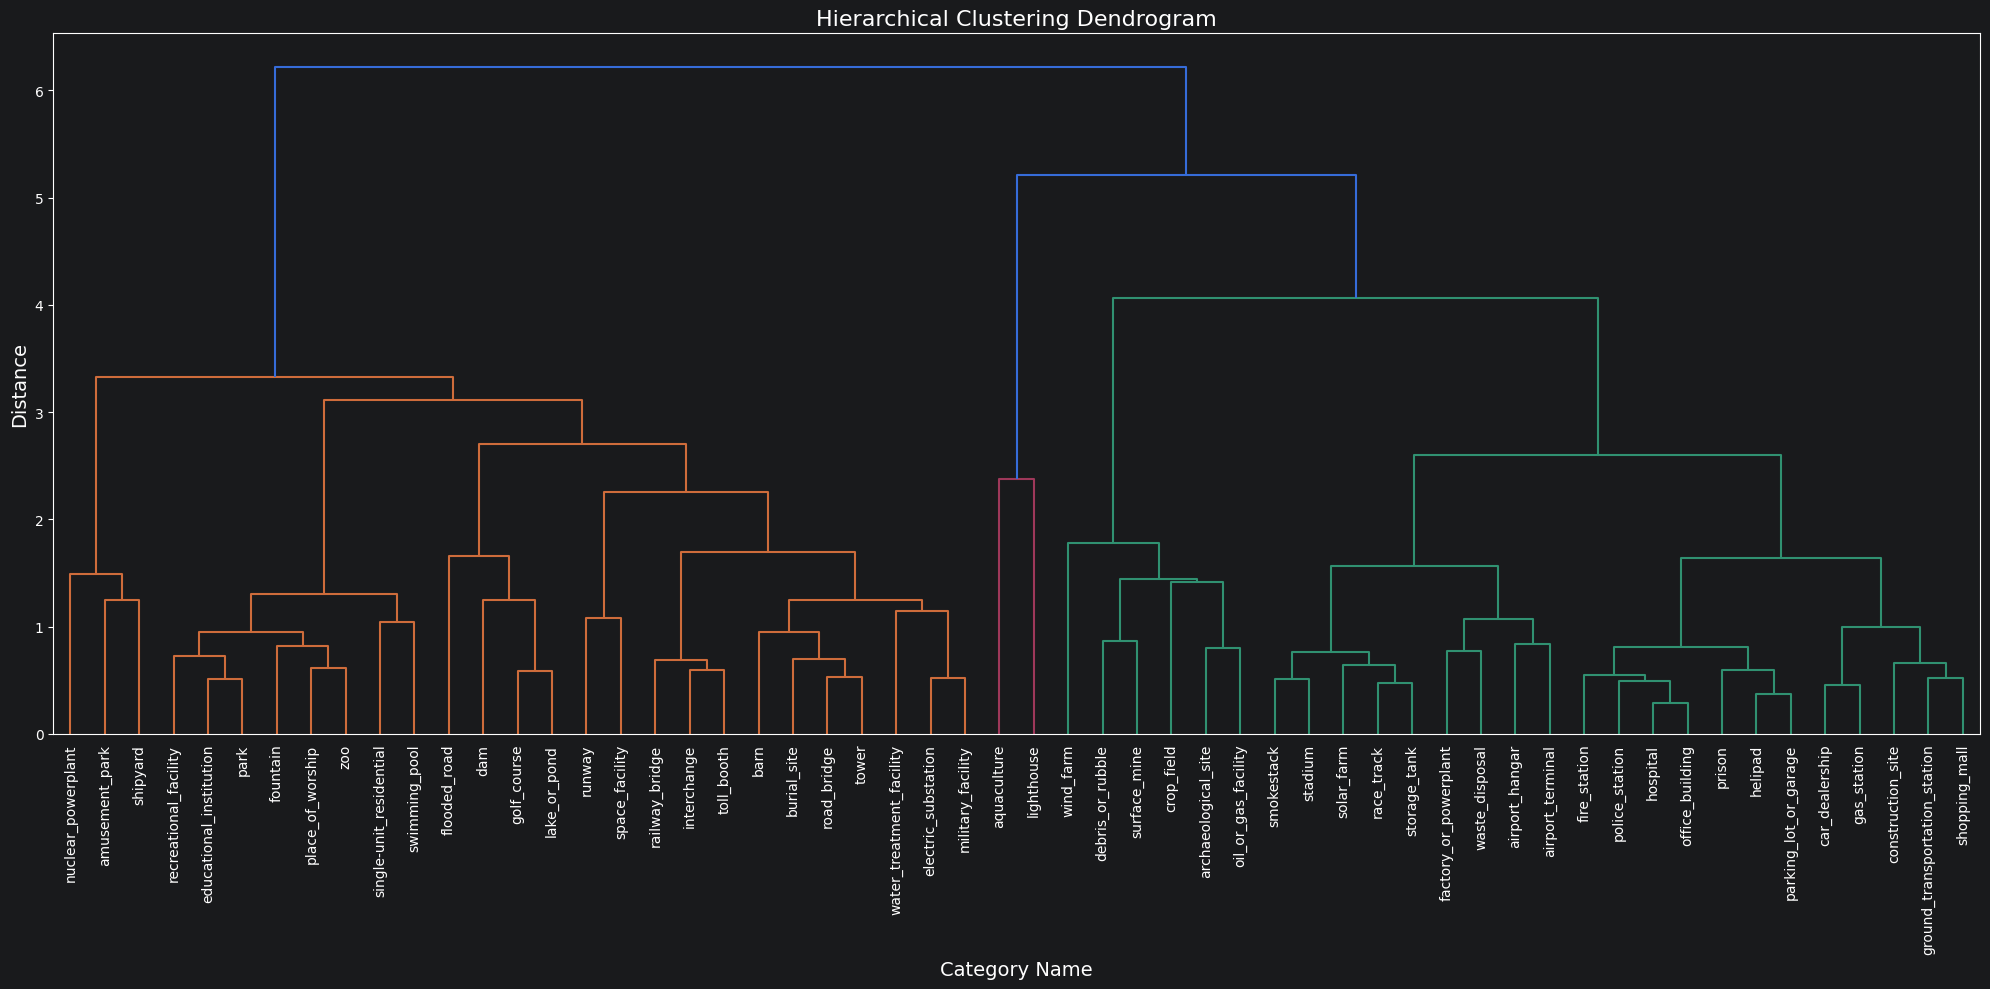

In [4]:
import FoundationModel
# 1. Setup the pipeline and get full raw metadata
pipeline = ClusteringPipeline.ClusteringPipeline()
df_full = pipeline.get_dataset()
fm_model_small = FoundationModel.FoundationModel(name='terramind_v1_small')
fm_model_tiny = FoundationModel.FoundationModel(name='terramind_v1_tiny')
df_sample = pipeline.sample_dataset(df_full, samples_per_class=100)

df_train_small = pipeline.get_embeddings(df_sample, fm_model_small, get_input, terramind_transform,save_path="./small")
df_train_small = pipeline.cluster_by_class(df_train_small, num_clusters=6)

df_train_tiny = pipeline.get_embeddings(df_sample, fm_model_tiny, get_input, terramind_transform,save_path = "./tiny")
df_train_tiny = pipeline.cluster_by_class(df_train_tiny, num_clusters=6)

embedding_dim_small = len(df_train_small['embedding'].iloc[0])
embedding_dim_tiny = len(df_train_tiny['embedding'].iloc[0])



In [5]:
mlp_model = LinearProbe(input_dim=embedding_dim_small, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_small,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 8.7% | Val Acc: 12.4%
Epoch [5/100] | Train Acc: 26.7% | Val Acc: 22.4%
Epoch [10/100] | Train Acc: 33.1% | Val Acc: 24.7%
Epoch [15/100] | Train Acc: 37.1% | Val Acc: 26.8%
Epoch [20/100] | Train Acc: 39.9% | Val Acc: 29.1%
Epoch [25/100] | Train Acc: 42.1% | Val Acc: 30.0%
Epoch [30/100] | Train Acc: 44.1% | Val Acc: 30.6%
Epoch [35/100] | Train Acc: 45.9% | Val Acc: 30.7%
Epoch [40/100] | Train Acc: 48.0% | Val Acc: 30.9%
Epoch [45/100] | Train Acc: 49.3% | Val Acc: 31.7%
Epoch [50/100] | Train Acc: 49.9% | Val Acc: 30.9%
Epoch [55/100] | Train Acc: 51.3% | Val Acc: 31.4%
Epoch [60/100] | Train Acc: 53.6% | Val Acc: 32.1%
Epoch [65/100] | Train Acc: 54.4% | Val Acc: 31.7%
Epoch [70/100] | Train Acc: 54.8% | Val Acc: 32.9%
Epoch [75/100] | Train Acc: 55.9% | Val Acc: 32.4%
Epoch [80/100] | Train Acc: 57.0% | Val Acc: 31.8%
Epoch [85/100] | Train Acc: 57.6% | Val Acc: 32.5%
Epoch [90/100] | Train Acc: 58.2% | V

In [6]:
mlp_model = LinearProbe(input_dim=embedding_dim_small, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_small,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/100] | Train Acc: 46.7% | Val Acc: 57.5%
Epoch [5/100] | Train Acc: 60.5% | Val Acc: 64.3%
Epoch [10/100] | Train Acc: 63.7% | Val Acc: 66.2%
Epoch [15/100] | Train Acc: 64.6% | Val Acc: 66.6%
Epoch [20/100] | Train Acc: 65.0% | Val Acc: 64.4%
Epoch [25/100] | Train Acc: 65.8% | Val Acc: 66.8%
Epoch [30/100] | Train Acc: 65.7% | Val Acc: 66.2%
Epoch [35/100] | Train Acc: 66.4% | Val Acc: 67.2%
Epoch [40/100] | Train Acc: 67.2% | Val Acc: 66.3%
Epoch [45/100] | Train Acc: 67.6% | Val Acc: 67.0%
Epoch [50/100] | Train Acc: 68.5% | Val Acc: 67.4%
Epoch [55/100] | Train Acc: 67.3% | Val Acc: 67.9%
Epoch [60/100] | Train Acc: 68.3% | Val Acc: 66.7%
Epoch [65/100] | Train Acc: 68.0% | Val Acc: 67.4%
Epoch [70/100] | Train Acc: 68.6% | Val Acc: 67.5%
Epoch [75/100] | Train Acc: 68.1% | Val Acc: 67.8%
Epoch [80/100] | Train Acc: 68.8% | Val Acc: 67.2%
Epoch [85/100] | Train Acc: 69.1% | Val Acc: 68.0%
Epoch [90/100] | Train Acc: 69.0%

In [7]:
mlp_model = LinearProbe(input_dim=embedding_dim_tiny, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_tiny,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/100] | Train Acc: 5.5% | Val Acc: 9.0%
Epoch [5/100] | Train Acc: 20.6% | Val Acc: 17.8%
Epoch [10/100] | Train Acc: 24.2% | Val Acc: 20.2%
Epoch [15/100] | Train Acc: 27.2% | Val Acc: 22.3%
Epoch [20/100] | Train Acc: 28.9% | Val Acc: 23.3%
Epoch [25/100] | Train Acc: 30.7% | Val Acc: 23.9%
Epoch [30/100] | Train Acc: 31.8% | Val Acc: 23.3%
Epoch [35/100] | Train Acc: 32.7% | Val Acc: 24.2%
Epoch [40/100] | Train Acc: 33.8% | Val Acc: 24.0%
Epoch [45/100] | Train Acc: 34.9% | Val Acc: 25.2%
Epoch [50/100] | Train Acc: 34.9% | Val Acc: 25.2%
Epoch [55/100] | Train Acc: 35.6% | Val Acc: 24.4%
Epoch [60/100] | Train Acc: 36.4% | Val Acc: 24.7%
Epoch [65/100] | Train Acc: 37.1% | Val Acc: 24.8%
Epoch [70/100] | Train Acc: 37.4% | Val Acc: 25.8%
Epoch [75/100] | Train Acc: 37.8% | Val Acc: 26.3%
Epoch [80/100] | Train Acc: 38.3% | Val Acc: 25.6%
Epoch [85/100] | Train Acc: 38.4% | Val Acc: 25.6%
Epoch [90/100] | Train Acc: 39.1% | Va

In [8]:
mlp_model = LinearProbe(input_dim=embedding_dim_tiny, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_tiny,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/100] | Train Acc: 43.8% | Val Acc: 52.3%
Epoch [5/100] | Train Acc: 57.8% | Val Acc: 57.4%
Epoch [10/100] | Train Acc: 60.2% | Val Acc: 58.2%
Epoch [15/100] | Train Acc: 61.6% | Val Acc: 58.5%
Epoch [20/100] | Train Acc: 62.4% | Val Acc: 59.7%
Epoch [25/100] | Train Acc: 62.8% | Val Acc: 59.3%
Epoch [30/100] | Train Acc: 63.6% | Val Acc: 59.8%
Epoch [35/100] | Train Acc: 63.3% | Val Acc: 59.9%
Epoch [40/100] | Train Acc: 63.5% | Val Acc: 59.8%
Epoch [45/100] | Train Acc: 64.0% | Val Acc: 59.6%
Epoch [50/100] | Train Acc: 63.8% | Val Acc: 59.4%
Epoch [55/100] | Train Acc: 64.1% | Val Acc: 59.6%
Epoch [60/100] | Train Acc: 64.6% | Val Acc: 60.0%
Epoch [65/100] | Train Acc: 64.6% | Val Acc: 59.6%
Epoch [70/100] | Train Acc: 65.1% | Val Acc: 59.6%
Epoch [75/100] | Train Acc: 65.1% | Val Acc: 60.6%
Epoch [80/100] | Train Acc: 65.1% | Val Acc: 59.5%
Epoch [85/100] | Train Acc: 65.5% | Val Acc: 60.3%
Epoch [90/100] | Train Acc: 65.4%

In [17]:
mlp_model = SimpleMLP(input_dim=embedding_dim_small, num_classes=6)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-3)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_small,
    criterion=criterion,
    optimizer=optimizer,
    target_col='macro_class',
    epochs=100
)

Preparing data for training on target: macro_class
Epoch [1/300] | Train Acc: 49.7% | Val Acc: 62.2%
Epoch [5/300] | Train Acc: 64.0% | Val Acc: 67.8%
Epoch [10/300] | Train Acc: 66.1% | Val Acc: 68.1%
Epoch [15/300] | Train Acc: 69.6% | Val Acc: 69.3%
Epoch [20/300] | Train Acc: 72.1% | Val Acc: 68.1%
Epoch [25/300] | Train Acc: 73.1% | Val Acc: 69.0%
Epoch [30/300] | Train Acc: 75.3% | Val Acc: 68.7%
Epoch [35/300] | Train Acc: 76.9% | Val Acc: 66.9%
Epoch [40/300] | Train Acc: 78.1% | Val Acc: 69.4%
Epoch [45/300] | Train Acc: 77.8% | Val Acc: 69.3%
Epoch [50/300] | Train Acc: 79.5% | Val Acc: 67.4%
Epoch [55/300] | Train Acc: 80.0% | Val Acc: 69.2%
Epoch [60/300] | Train Acc: 81.1% | Val Acc: 66.7%
Epoch [65/300] | Train Acc: 81.2% | Val Acc: 67.7%
Epoch [70/300] | Train Acc: 82.1% | Val Acc: 66.6%
Epoch [75/300] | Train Acc: 82.2% | Val Acc: 67.1%
Epoch [80/300] | Train Acc: 83.2% | Val Acc: 67.8%
Epoch [85/300] | Train Acc: 83.7% | Val Acc: 66.9%
Epoch [90/300] | Train Acc: 85.4%

In [19]:
mlp_model = SimpleMLP(input_dim=embedding_dim_tiny, num_classes=62)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(mlp_model.parameters(), lr=1e-2)

# Train using the newly created macro_class column
history = pipeline.train_offline(
    model=mlp_model,
    df=df_train_tiny,
    criterion=criterion,
    optimizer=optimizer,
    target_col='category',
    epochs=100
)

Preparing data for training on target: category
Epoch [1/400] | Train Acc: 10.2% | Val Acc: 17.0%
Epoch [5/400] | Train Acc: 22.4% | Val Acc: 21.6%
Epoch [10/400] | Train Acc: 25.5% | Val Acc: 23.3%
Epoch [15/400] | Train Acc: 27.6% | Val Acc: 23.7%
Epoch [20/400] | Train Acc: 29.4% | Val Acc: 23.9%
Epoch [25/400] | Train Acc: 30.7% | Val Acc: 25.3%
Epoch [30/400] | Train Acc: 31.9% | Val Acc: 25.9%
Epoch [35/400] | Train Acc: 32.0% | Val Acc: 24.7%
Epoch [40/400] | Train Acc: 32.9% | Val Acc: 27.0%
Epoch [45/400] | Train Acc: 33.3% | Val Acc: 23.8%
Epoch [50/400] | Train Acc: 33.0% | Val Acc: 25.9%
Epoch [55/400] | Train Acc: 34.6% | Val Acc: 24.6%
Epoch [60/400] | Train Acc: 34.7% | Val Acc: 25.0%
Epoch [65/400] | Train Acc: 35.1% | Val Acc: 23.7%
Epoch [70/400] | Train Acc: 35.6% | Val Acc: 24.5%
Epoch [75/400] | Train Acc: 35.2% | Val Acc: 25.7%
Epoch [80/400] | Train Acc: 35.6% | Val Acc: 24.5%
Epoch [85/400] | Train Acc: 35.7% | Val Acc: 23.9%
Epoch [90/400] | Train Acc: 36.6% | 

KeyboardInterrupt: 